# **Shelter Occupancy Analysis**

## **Pre: Basic Data Cleaning**

In [ ]:
import pandas as pd
import numpy as np
import re


url = "https://github.com/Tantrayoga/Toronto_Shelter_System/raw/main/Datasets/public_services_dataset.csv"

df = pd.read_csv(
    url,
    dtype={"LOCATION_POSTAL_CODE": "string"},   # keep postal codes as text
    parse_dates=["OCCUPANCY_DATE"]             # parse date column
)

print(df.shape)
df.head()

(100337, 11)


,OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE
0,2024-01-01,M9W1J1,Families,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,149,149,1,1.0
1,2024-01-01,M9W1J1,Mixed Adult,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,57,57,0,1.0
2,2024-01-01,M5S2P1,Mixed Adult,Shelter,Emergency,Base Program - Refugee,Bed Based Capacity,8,8,0,1.0
3,2024-01-01,M2J4R1,Families,Motel/Hotel Shelter,Emergency,Temporary Programs,Room Based Capacity,67,67,16,1.0
4,2024-01-01,M2J4R1,Families,Motel/Hotel Shelter,Emergency,Temporary Refugee Response,Room Based Capacity,161,161,0,1.0


In [ ]:
# Change postal code to be the same structure
postal = (
    df["LOCATION_POSTAL_CODE"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", "", regex=True)
)

# convert literal "NAN" to real missing
postal = postal.replace("NAN", pd.NA)

df["LOCATION_POSTAL_CODE"] = postal

In [ ]:
to_drop = df["LOCATION_POSTAL_CODE"].isna().sum()
print("Rows with missing/NAN postal code:", int(to_drop))

Rows with missing/NAN postal code: 4512


In [ ]:
# Drop values with missing postal code
df_no_nan_postal = df.dropna(subset=["LOCATION_POSTAL_CODE"]).copy()
print("After:", df_no_nan_postal.shape)

After: (95825, 11)


In [ ]:
# Check for NaNs in other rows
missing = df_no_nan_postal.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)

pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).query("missing_count > 0")

,missing_count,missing_pct
PROGRAM_MODEL,4,0.004


In [ ]:
missing_pm = df["PROGRAM_MODEL"].isna().sum()
print("Rows with missing PROGRAM_MODEL:", int(missing_pm))

Rows with missing PROGRAM_MODEL: 4


In [ ]:
# Clean it again
df_cleaned = df_no_nan_postal.dropna(subset=["PROGRAM_MODEL"]).copy()
print("Before:", df_no_nan_postal.shape)
print("After :", df_cleaned.shape)

Before: (95825, 11)
After : (95821, 11)


## **First Analysis: Occupancy Analysis by Data Analysis and Visualization**

In [ ]:
# Check the existency of invalid Postal Codes
pc_re = re.compile(r"^[A-Z]\d[A-Z]\d[A-Z]\d$")

df_cleaned["POSTAL_VALID_FLAG"] = (
    df_cleaned["LOCATION_POSTAL_CODE"].fillna("").str.match(pc_re)
).astype(int)

print("Invalid postal count:", int((df_cleaned["POSTAL_VALID_FLAG"]==0).sum()))
df_cleaned.loc[df_cleaned["POSTAL_VALID_FLAG"]==0, "LOCATION_POSTAL_CODE"].value_counts()

Invalid postal count: 334


,count
LOCATION_POSTAL_CODE,
M9W1J,334


In [ ]:
# As the only possible FSA for M9W1J is M9W in GTA, then we didn't dropped it. For df_awareness, we changed the location postal code into FSA (first 3 postal codes)
import pandas as pd

# Create df_awareness from df_cleaned
df_awareness = df_cleaned.copy()

# We convert full postal codes to FSA (first 3 characters) because FSA is an area-level geograph that is easier to map consistently.
# The dataset does not provide a unique shelter ID, so multiple records can exist within the same area. We therefore aggregate at the FSA level for visualization,
# while still preserving key operational segments (SECTOR and CAPACITY_TYPE).

# Standardize postal codes
df_awareness["LOCATION_POSTAL_CODE"] = (
    df_awareness["LOCATION_POSTAL_CODE"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", "", regex=True)
)

# Replace LOCATION_POSTAL_CODE with FSA
df_awareness["LOCATION_POSTAL_CODE"] = df_awareness["LOCATION_POSTAL_CODE"].str[:3]  # FSA

# 2) Aggregate (sum) capacities within the same DATE + FSA + SECTOR + CAPACITY_TYPE
df_awareness_daily = (
    df_awareness
    .groupby(["OCCUPANCY_DATE", "LOCATION_POSTAL_CODE", "SECTOR", "CAPACITY_TYPE"], as_index=False)
    .agg(
        ACTUAL_CAPACITY=("ACTUAL_CAPACITY", "sum"),
        OCCUPIED_CAPACITY=("OCCUPIED_CAPACITY", "sum"),
        UNAVAILABLE_CAPACITY=("UNAVAILABLE_CAPACITY", "sum"),
    )
)

# Recompute occupancy rate after aggregation
df_awareness_daily["OCCUPANCY_RATE"] = (
    df_awareness_daily["OCCUPIED_CAPACITY"] / df_awareness_daily["ACTUAL_CAPACITY"]
)

# 3) Quick checks
print("df_awareness (row-level, FSA) shape:", df_awareness.shape)
print("df_awareness_daily (aggregated) shape:", df_awareness_daily.shape)
df_awareness_daily.head()

df_awareness (row-level, FSA) shape: (95821, 12)
df_awareness_daily (aggregated) shape: (62456, 8)


,OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SECTOR,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,UNAVAILABLE_CAPACITY,OCCUPANCY_RATE
0,2024-01-01,L4L,Mixed Adult,Room Based Capacity,69,66,0,0.956522
1,2024-01-01,M1B,Women,Room Based Capacity,103,103,0,1.000000
2,2024-01-01,M1E,Families,Room Based Capacity,113,113,0,1.000000
3,2024-01-01,M1E,Mixed Adult,Bed Based Capacity,89,89,0,1.000000
4,2024-01-01,M1E,Youth,Room Based Capacity,46,46,0,1.000000


In [ ]:
# df_awareness OCCUPANCY_DATE, FSA, SECTOR, CAPACITY_TYPE, ACTUAL, OCCUPIED
df_2025 = df_awareness_daily[df_awareness_daily["OCCUPANCY_DATE"].dt.year == 2025].copy()

fsa_2025 = (df_2025.groupby(["LOCATION_POSTAL_CODE","SECTOR","CAPACITY_TYPE"], as_index=False)
              .agg(ACTUAL_CAPACITY=("ACTUAL_CAPACITY","sum"),
                   OCCUPIED_CAPACITY=("OCCUPIED_CAPACITY","sum")))

fsa_2025["OCCUPANCY_RATE"] = fsa_2025["OCCUPIED_CAPACITY"] / fsa_2025["ACTUAL_CAPACITY"]
fsa_2025.rename(columns={"LOCATION_POSTAL_CODE":"FSA"}, inplace=True)

In [ ]:
!pip -q install geopandas

import requests
import geopandas as gpd

# Extracting official StatCan boundaries for Toronto (M-Postal Codes) and Vaughan (L4L) to enable spatial joins.
base = "https://geo.statcan.gc.ca/geo_wa/rest/services/2021/Cartographic_boundary_files/MapServer/14/query"
where = "PRUID='35' AND (CFSAUID LIKE 'M%' OR CFSAUID='L4L')"

# Count first
params_count = {"where": where, "returnCountOnly": "true", "f": "json"}
n = requests.get(base, params=params_count).json().get("count", 0)
print("Count features:", n)

# Fetch in one go (should be small), but keep pagination-safe anyway
features = []
page_size = 2000

for offset in range(0, n, page_size):
    params = {
        "where": where,
        "outFields": "CFSAUID,PRUID,PRNAME,LANDAREA",
        "returnGeometry": "true",
        "outSR": "4326",
        "f": "geojson",
        "resultOffset": offset,
        "resultRecordCount": page_size
    }
    r = requests.get(base, params=params)
    r.raise_for_status()
    gj = r.json()
    features.extend(gj["features"])

gdf_fsa = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
gdf_fsa = gdf_fsa.rename(columns={"CFSAUID": "FSA"})

# This GeoDataFrame serves as our 'Spatial Anchor,' allowing us to heat-map occupancy pressure across the GTA.
print("Boundary loaded:", gdf_fsa.shape)
gdf_fsa[["FSA","PRNAME","LANDAREA"]].head()

In [ ]:
gdf_fsa.to_file("fsa_boundary_M_and_L4L.geojson", driver="GeoJSON")
print("Saved: fsa_boundary_M_and_L4L.geojson")

In [ ]:
df_map = df_awareness_daily.rename(columns={"LOCATION_POSTAL_CODE": "FSA"}).copy()

# 2025 aggregated occupancy per FSA + segment
df_2025 = df_map[df_map["OCCUPANCY_DATE"].dt.year == 2025].copy()

fsa_2025 = (df_2025.groupby(["FSA","SECTOR","CAPACITY_TYPE"], as_index=False)
              .agg(ACTUAL_CAPACITY=("ACTUAL_CAPACITY","sum"),
                   OCCUPIED_CAPACITY=("OCCUPIED_CAPACITY","sum")))

fsa_2025["OCCUPANCY_RATE"] = fsa_2025["OCCUPIED_CAPACITY"] / fsa_2025["ACTUAL_CAPACITY"]

gdf_map = gdf_fsa.merge(fsa_2025, on="FSA", how="left")
gdf_map.head()

In [ ]:
fsa_2025.to_csv("fsa_2025.csv", index=False)

In [ ]:
import plotly.express as px
from IPython.display import display, HTML
import pandas as pd

# STEP 0: FILTERING DATA
df_2025 = df_awareness[df_awareness['OCCUPANCY_DATE'].dt.year == 2025].copy()


# STEP 1: THE "WHO" (Demographics / Sector)
display(HTML("<h3>1. The 'Who': Occupancy by Demographic Sector</h3>"))
sector_stats = df_2025.groupby('SECTOR', as_index=False).agg(
    TOTAL_CAPACITY=('ACTUAL_CAPACITY', 'sum'),
    TOTAL_OCCUPIED=('OCCUPIED_CAPACITY', 'sum')
)
sector_stats['OCCUPANCY_RATE'] = sector_stats['TOTAL_OCCUPIED'] / sector_stats['TOTAL_CAPACITY']
sector_stats = sector_stats.sort_values(by='OCCUPANCY_RATE', ascending=False)

fig1 = px.bar(sector_stats, x='SECTOR', y='OCCUPANCY_RATE', color='SECTOR',
              title="2025 Occupancy Rate by Sector", text_auto='.2%', template="plotly_white")
fig1.update_layout(yaxis_tickformat='.0%', yaxis_title="Occupancy Rate")
fig1.show()

# STEP 2: THE "WHERE" (Geography / Postal Code Hotspots)
display(HTML("<hr><h3>2. The 'Where': Most Crowded Postal Codes (Hotspots)</h3>"))
area_stats = df_2025.groupby('LOCATION_POSTAL_CODE', as_index=False).agg(
    AVG_UNAVAILABLE=('UNAVAILABLE_CAPACITY', 'mean'),
    TOTAL_CAPACITY=('ACTUAL_CAPACITY', 'sum'),
    TOTAL_OCCUPIED=('OCCUPIED_CAPACITY', 'sum')
)
area_stats['OCCUPANCY_RATE'] = area_stats['TOTAL_OCCUPIED'] / area_stats['TOTAL_CAPACITY']

worst_areas = area_stats.sort_values(by='OCCUPANCY_RATE', ascending=False).head(5)
display(worst_areas[['LOCATION_POSTAL_CODE', 'OCCUPANCY_RATE', 'AVG_UNAVAILABLE']])



# STEP 3: THE "WHEN" (Seasonality by Occupancy Rate)
display(HTML("<hr><h3>3. The 'When': Seasonality by True Occupancy Rate</h3>"))

# Make sure we have the month name
df_2025['MONTH'] = df_2025['OCCUPANCY_DATE'].dt.month_name()

# To get the true rate, we sum all actual and occupied beds for the whole month
monthly_occ = df_2025.groupby('MONTH', as_index=False).agg(
    TOTAL_ACTUAL=('ACTUAL_CAPACITY', 'sum'),
    TOTAL_OCCUPIED=('OCCUPIED_CAPACITY', 'sum')
)

# Calculate the true monthly occupancy rate percentage
monthly_occ['OCCUPANCY_RATE'] = monthly_occ['TOTAL_OCCUPIED'] / monthly_occ['TOTAL_ACTUAL']

# Sort months chronologically for the chart
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_occ['MONTH'] = pd.Categorical(monthly_occ['MONTH'], categories=months_order, ordered=True)
monthly_occ = monthly_occ.sort_values('MONTH')

# Print the top 3 worst (most full) months
worst_months = monthly_occ.sort_values('OCCUPANCY_RATE', ascending=False).head(3)
print("Top 3 Worst Months by Occupancy Rate:")
display(worst_months[['MONTH', 'OCCUPANCY_RATE']])

# Plot the new Line Chart!
fig3 = px.line(monthly_occ, x='MONTH', y='OCCUPANCY_RATE', markers=True,
               title="2025 Trend: True Occupancy Rate per Month",
               template="plotly_dark")

# Format the Y-axis as a percentage so it looks professional
fig3.update_layout(yaxis_tickformat='.2%', yaxis_title="Occupancy Rate")
fig3.update_traces(line=dict(color="#ff4b4b", width=3), marker=dict(size=8))
fig3.show()


# STEP 4: THE "WHAT" (Program Funding Areas)
display(HTML("<hr><h3>4. The 'What': Occupancy by Funding Program Area</h3>"))
prog_area_stats = df_2025.groupby('PROGRAM_AREA', as_index=False).agg(
    TOTAL_CAPACITY=('ACTUAL_CAPACITY', 'sum'),
    TOTAL_OCCUPIED=('OCCUPIED_CAPACITY', 'sum')
)
prog_area_stats['OCCUPANCY_RATE'] = prog_area_stats['TOTAL_OCCUPIED'] / prog_area_stats['TOTAL_CAPACITY']
prog_area_stats = prog_area_stats.sort_values(by='OCCUPANCY_RATE', ascending=False)

fig4 = px.bar(
    prog_area_stats, x='PROGRAM_AREA', y='OCCUPANCY_RATE', color='PROGRAM_AREA',
    title="2025 Occupancy Rate by Program Area", text_auto='.2%', template="plotly_white"
)
fig4.update_layout(yaxis_tickformat='.0%', yaxis_title="Occupancy Rate", xaxis_tickangle=-15)
fig4.show()

,LOCATION_POSTAL_CODE,OCCUPANCY_RATE,AVG_UNAVAILABLE
45,M6R,1.000000,0.553425
47,M8Y,0.999929,1.075342
10,M1T,0.999927,46.050847
12,M2J,0.999502,3.508831
1,M1B,0.999255,3.079452


Top 3 Worst Months by Occupancy Rate:


,MONTH,OCCUPANCY_RATE
8,May,0.986698
10,October,0.985697
0,April,0.985648


In [ ]:
import pandas as pd

# 1. Get the total beds for each exact day across the whole city
daily_totals = df_2025.groupby('OCCUPANCY_DATE', as_index=False).agg(
    TOTAL_ACTUAL_BEDS=('ACTUAL_CAPACITY', 'sum'),
    TOTAL_OCCUPIED_BEDS=('OCCUPIED_CAPACITY', 'sum')
)

# 2. Extract the month name
daily_totals['MONTH'] = daily_totals['OCCUPANCY_DATE'].dt.month_name()

# 3. Find the average daily beds for each month
monthly_absolute = daily_totals.groupby('MONTH', as_index=False).agg(
    AVG_DAILY_CAPACITY=('TOTAL_ACTUAL_BEDS', 'mean'),
    AVG_DAILY_OCCUPIED=('TOTAL_OCCUPIED_BEDS', 'mean')
)

# 4. Sort chronologically
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_absolute['MONTH'] = pd.Categorical(monthly_absolute['MONTH'], categories=months_order, ordered=True)
monthly_absolute = monthly_absolute.sort_values('MONTH').dropna()

# 5. Round the numbers to make them easy to read
monthly_absolute['AVG_DAILY_CAPACITY'] = monthly_absolute['AVG_DAILY_CAPACITY'].round(0).astype(int)
monthly_absolute['AVG_DAILY_OCCUPIED'] = monthly_absolute['AVG_DAILY_OCCUPIED'].round(0).astype(int)

print("--- ABSOLUTE BEDS PER MONTH (2025) ---")
print(monthly_absolute.to_string(index=False))

--- ABSOLUTE BEDS PER MONTH (2025) ---
    MONTH  AVG_DAILY_CAPACITY  AVG_DAILY_OCCUPIED
  January                7735                7598
 February                7748                7590
    March                7437                7285
    April                7058                6957
      May                6826                6736
     June                6790                6657
     July                6694                6538
   August                6547                6426
September                6434                6332
  October                6416                6325
 November                6556                6384
 December                6951                6752


In [ ]:
import plotly.graph_objects as go
from IPython.display import display, HTML
import pandas as pd

display(HTML("<h3>Hypothesis Test: Absolute Capacity vs. Absolute Occupied (2025)</h3>"))

# 1. Group by exact Date first to get the total beds per day across the whole city
daily_totals = df_2025.groupby('OCCUPANCY_DATE', as_index=False).agg(
    TOTAL_ACTUAL_BEDS=('ACTUAL_CAPACITY', 'sum'),
    TOTAL_OCCUPIED_BEDS=('OCCUPIED_CAPACITY', 'sum')
)

# 2. Extract the month
daily_totals['MONTH'] = daily_totals['OCCUPANCY_DATE'].dt.month_name()

# 3. Find the Average Daily Beds per month
hypothesis_test = daily_totals.groupby('MONTH', as_index=False).agg(
    AVG_DAILY_CAPACITY=('TOTAL_ACTUAL_BEDS', 'mean'),
    AVG_DAILY_OCCUPIED=('TOTAL_OCCUPIED_BEDS', 'mean')
)

# 4. Sort chronologically
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
hypothesis_test['MONTH'] = pd.Categorical(hypothesis_test['MONTH'], categories=months_order, ordered=True)
hypothesis_test = hypothesis_test.sort_values('MONTH')

display(hypothesis_test)

# 5. Plot the absolute numbers to see the gap!
fig_hyp = go.Figure()
fig_hyp.add_trace(go.Bar(x=hypothesis_test['MONTH'], y=hypothesis_test['AVG_DAILY_CAPACITY'],
                         name='Total Capacity (Beds Available)', marker_color='lightgray'))
fig_hyp.add_trace(go.Bar(x=hypothesis_test['MONTH'], y=hypothesis_test['AVG_DAILY_OCCUPIED'],
                         name='Occupied Beds (People Sheltered)', marker_color='#ff4b4b'))

fig_hyp.update_layout(
    title="The Friend's Hypothesis: Absolute Capacity vs Absolute Occupied",
    barmode='overlay', # This overlaps the bars so you can easily see the gap!
    template="plotly_white",
    yaxis_title="Total Number of Beds/People"
)
fig_hyp.show()

,MONTH,AVG_DAILY_CAPACITY,AVG_DAILY_OCCUPIED
4,January,7734.548387,7597.741935
3,February,7747.678571,7589.678571
7,March,7437.483871,7285.258065
0,April,7058.100000,6956.800000
8,May,6826.483871,6735.677419
6,June,6790.233333,6656.733333
5,July,6694.000000,6538.000000
1,August,6547.483871,6426.387097
11,September,6433.600000,6332.166667
10,October,6416.451613,6324.677419


## **Second Analysis: Occupancy Analysis by Predictive Model**

### **More Data Cleaning**

In [ ]:
# Check the existence of invalid Postal Codes
pc_re = re.compile(r"^[A-Z]\d[A-Z]\d[A-Z]\d$")

df_cleaned["POSTAL_VALID_FLAG"] = (
    df_cleaned["LOCATION_POSTAL_CODE"].fillna("").str.match(pc_re)
).astype(int)

print("Invalid postal count:", int((df_cleaned["POSTAL_VALID_FLAG"]==0).sum()))
df_cleaned.loc[df_cleaned["POSTAL_VALID_FLAG"]==0, "LOCATION_POSTAL_CODE"].value_counts()

Invalid postal count: 334


,count
LOCATION_POSTAL_CODE,
M9W1J,334


In [ ]:
# We assume those entries are invalid, since this dataset is specifically for training model,
# and we need clear information of all the data from each row
df_cleaned_v2 = df_cleaned[df_cleaned["POSTAL_VALID_FLAG"] == 1]
df_cleaned_v2.shape

(95487, 12)

In [ ]:
# When analyzing, we noticed some entries with identical group from some categories have different capacities
# This means we need to merge those entries as to not confuse the model

# Define the columns that make each group unique
grouping_cols = [
    'OCCUPANCY_DATE',
    'LOCATION_POSTAL_CODE',
    'SECTOR',
    'OVERNIGHT_SERVICE_TYPE',
    'PROGRAM_MODEL',
    'PROGRAM_AREA',
    'CAPACITY_TYPE'
]

# Aggregate the numeric values
# We sum the beds to get the 'Total Neighborhood Capacity'
df_grouped = df_cleaned_v2.groupby(grouping_cols).agg({
    'ACTUAL_CAPACITY': 'sum',
    'OCCUPIED_CAPACITY': 'sum'
}).reset_index()

# Re-calculate the Rate for the group
# This is more accurate than averaging the individual rates
df_grouped['OCCUPANCY_RATE'] = df_grouped['OCCUPIED_CAPACITY'] / df_grouped['ACTUAL_CAPACITY']

# Handle any potential division by zero (if a shelter had 0 capacity)
df_grouped['OCCUPANCY_RATE'] = df_grouped['OCCUPANCY_RATE'].fillna(0)

df_grouped.head()

,OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,OCCUPANCY_RATE
0,2024-01-01,L4L8P5,Mixed Adult,Motel/Hotel Shelter,Emergency,Temporary Programs,Room Based Capacity,69,66,0.956522
1,2024-01-01,M1B3M6,Women,Motel/Hotel Shelter,Emergency,Temporary Programs,Room Based Capacity,103,103,1.000000
2,2024-01-01,M1E2M6,Families,Shelter,Emergency,Base Shelter and Overnight Services System,Room Based Capacity,44,44,1.000000
3,2024-01-01,M1E2N8,Families,Motel/Hotel Shelter,Emergency,Base Shelter and Overnight Services System,Room Based Capacity,20,20,1.000000
4,2024-01-01,M1E2P4,Youth,Motel/Hotel Shelter,Emergency,Temporary Programs,Room Based Capacity,46,46,1.000000


In [ ]:
# Extract the Month (1-12)
df_grouped['month'] = df_grouped['OCCUPANCY_DATE'].dt.month

# Extract the Day of the Week (0 = Monday, 6 = Sunday)
df_grouped['day_of_week'] = df_grouped['OCCUPANCY_DATE'].dt.dayofweek

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Create a combined 'Strata' column to apply stratified sampling
# Highlighted features for the strata are Sector and Capacity Type
df_grouped['strata'] = df_grouped['SECTOR'] + "_" + df_grouped["CAPACITY_TYPE"]

# List all the columns
categorical_cols = ['LOCATION_POSTAL_CODE', 'SECTOR', 'PROGRAM_AREA',
                    'PROGRAM_MODEL', 'OVERNIGHT_SERVICE_TYPE', 'CAPACITY_TYPE']

le = LabelEncoder()

mapping_dict = {}

for col in categorical_cols:
    # We create a new column with the suffix _encoded
    df_grouped[f'{col}_encoded'] = le.fit_transform(df_grouped[col].astype(str))
    # This stores the link between the number and the original text
    mapping_dict[col] = dict(zip(le.transform(le.classes_), le.classes_))

### **Training and Testing Predictive Model**

The model we used is a Gradient Boosting Regressor, implemented with HistGradientBoostingRegressor from scikit.learn.

The baseline we used is the expected value of occupancy rate given just the Sector. In other words, we calculate $E[Sector]$.

We also use 80/20 train-test split, using stratified sampling based on Sector and Capacity Type.

In [ ]:
# Split the dataset using stratified sampling
df_train, df_test = train_test_split(
    df_grouped,
    test_size=0.2,
    random_state=42, # to ensure reproducibility
    stratify=df_grouped['strata']
)

In [ ]:
# Run a baseline model

# 1. Calculate the 'Normal' occupancy for each Sector in your training data
sector_averages = df_train.groupby('SECTOR')['OCCUPANCY_RATE'].mean()

# 2. 'Predict' the test set by just giving every row its Sector's average
df_test['baseline_pred'] = df_test['SECTOR'].map(sector_averages)

# 3. Calculate the Error (MAE)
baseline_mae = mean_absolute_error(df_test['OCCUPANCY_RATE'], df_test['baseline_pred'])

print(f"Sector-Based Mean Baseline MAE: {baseline_mae:.4f}")

Sector-Based Mean Baseline MAE: 0.0439


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt

# Define the feature list (make sure all features are numerical)
features = [
    'LOCATION_POSTAL_CODE_encoded',
    'SECTOR_encoded',
    'PROGRAM_AREA_encoded',
    'PROGRAM_MODEL_encoded',
    'OVERNIGHT_SERVICE_TYPE_encoded',
    'CAPACITY_TYPE_encoded',
    'month',
    'day_of_week'
]

X_train = df_train[features]
y_train = df_train['OCCUPANCY_RATE']
X_test = df_test[features]
y_test = df_test['OCCUPANCY_RATE']

# Initialize the Gradient Boosting Regressor Model
# We set categorical_features so the model treats those IDs correctly
# Indices 0 through 5 are our categorical encoded columns
# We can also include 6 and 7, but it is not necessarily categorical as these have an order
model = HistGradientBoostingRegressor(
    categorical_features=[0, 1, 2, 3, 4, 5],
    random_state=42,
    learning_rate=0.05,
    max_iter=200,
)

# Train the Model
model.fit(X_train, y_train)

# Predict and Evaluate
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Model Training Complete!")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-Squared (Accuracy Score): {r2:.4f}")

Model Training Complete!
Mean Absolute Error (MAE): 0.0217
R-Squared (Accuracy Score): 0.5831


### **Analysis for Gradient Boosting Regressor Model**

Clipping rate: 0.00%
MAE:  0.0217
RMSE: 0.0594
MAPE (careful if near 0):  3.59%
sMAPE: 2.77%


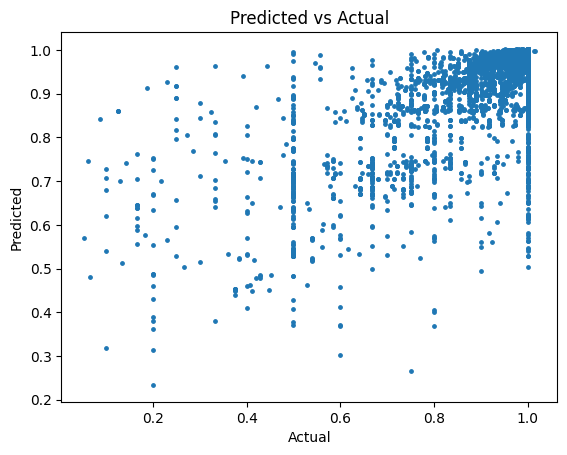

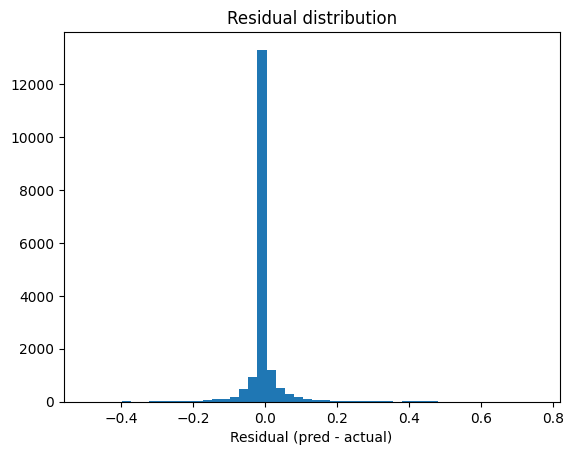

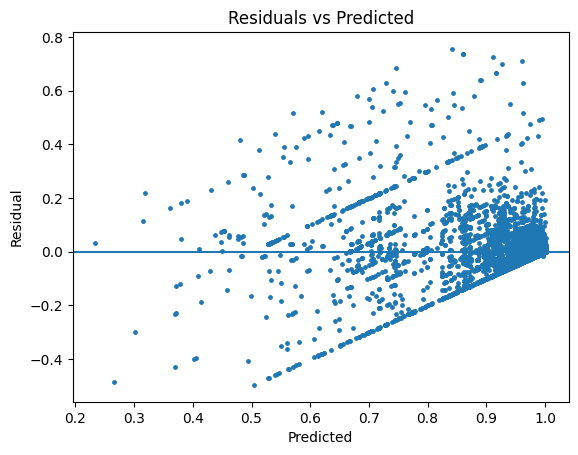

Found 27 Postal Codes where the model isn't much better (or maybe worse) than the baseline:
                      model_error  baseline_error      diff
LOCATION_POSTAL_CODE                                       
M5R2T8                   0.160825        0.123484  0.037341
M2N4N4                   0.148356        0.123717  0.024640
M1G1J6                   0.112543        0.103603  0.008941
M5V3C6                   0.039853        0.033467  0.006386
M5G1P4                   0.071661        0.066812  0.004849
M5T2V4                   0.022619        0.021701  0.000918
M6K3C3                   0.029142        0.028489  0.000653
M5C1K6                   0.050132        0.049585  0.000547
M5V3W3                   0.044851        0.044832  0.000020
M6G2C4                   0.045581        0.045569  0.000012
M5T2V5                   0.009492        0.009681 -0.000189
M5V2H3                   0.031407        0.032322 -0.000915
M5A2A5                   0.014510        0.015682 -0.001172
M5S2P1  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Predict
preds_raw = model.predict(X_test)

# --- GUARDRAILS (pick the correct one) ---

# If your target is AVAILABLE BEDS (your current setup):
preds = np.clip(preds_raw, 0, None)   # no negative free beds

# If your target was OCCUPANCY_RATE instead, use:
# preds = np.clip(preds_raw, 0, 1)

# Report how often clipping happened
clip_rate = np.mean(preds != preds_raw)
print(f"Clipping rate: {clip_rate:.2%}")

# Core metrics
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# MAPE / sMAPE (ONLY if y_test is not often near 0)
# For available beds, MAPE can explode if true value is 0 or near 0.
eps = 1e-6
mape = np.mean(np.abs((y_test - preds) / (np.abs(y_test) + eps))) * 100
smape = np.mean(2*np.abs(preds - y_test) / (np.abs(y_test) + np.abs(preds) + eps)) * 100
print(f"MAPE (careful if near 0):  {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

# Calibration-ish plots: Pred vs Actual and residuals
resid = preds - y_test

plt.figure()
plt.scatter(y_test, preds, s=6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

plt.figure()
plt.hist(resid, bins=50)
plt.xlabel("Residual (pred - actual)")
plt.title("Residual distribution")
plt.show()

plt.figure()
plt.scatter(preds, resid, s=6)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()

# Error slicing (requires df_test to still have the original columns)
df_err = df_test.copy()
df_err["y_true"] = y_test.values
df_err["y_pred"] = preds

# Calculate Absolute Errors for both models in your results dataframe
df_err['model_error'] = (df_err['OCCUPANCY_RATE'] - df_err['y_pred']).abs()
df_err['baseline_error'] = (df_err['OCCUPANCY_RATE'] - df_err['baseline_pred']).abs()

# Group by Postal Code and calculate the Mean Absolute Error (MAE) for both
comparison = df_err.groupby('LOCATION_POSTAL_CODE').agg({
    'model_error': 'mean',
    'baseline_error': 'mean'
})

# Create a column to see the difference (positive means model is WORSE)
comparison['diff'] = comparison['model_error'] - comparison['baseline_error']

# Filter for only the ones where the model performed NOT MUCH BETTER than the baseline
worse_than_baseline = comparison[comparison['diff'] > -0.01].sort_values(by='diff', ascending=False)

print(f"Found {len(worse_than_baseline)} Postal Codes where the model isn't much better (or maybe worse) than the baseline:")
print(worse_than_baseline)

In [ ]:
import numpy as np
import pandas as pd

# Assumes the following have already existed:
# - df_test (the test dataframe with original columns like SECTOR, CAPACITY_TYPE, etc.)
# - y_test (true OCCUPANCY_RATE for df_test)
# - preds (model predictions for OCCUPANCY_RATE)
# If you only have preds_raw, clip to [0,1] first:
preds = np.clip(preds, 0, 1)

# Build an error analysis frame
df_err = df_test.copy()
df_err["y_true"] = y_test.values
df_err["y_pred"] = preds
df_err["abs_err"] = np.abs(df_err["y_true"] - df_err["y_pred"])

# ---------------------------
# Slice 1) MAE by SECTOR
# ---------------------------
mae_by_sector = (
    df_err.groupby("SECTOR")["abs_err"]
    .mean()
    .sort_values(ascending=False)
)

print("\nMAE by SECTOR (worst first):")
print(mae_by_sector.head(20))

# ---------------------------
# Slice 2) MAE by CAPACITY_TYPE
# ---------------------------
mae_by_cap_type = (
    df_err.groupby("CAPACITY_TYPE")["abs_err"]
    .mean()
    .sort_values(ascending=False)
)

print("\nMAE by CAPACITY_TYPE (worst first):")
print(mae_by_cap_type)

# ---------------------------
# Slice 3) Near-full vs not (decision-critical)
# Threshold: 0.95
# ---------------------------
NEAR_FULL_THR = 0.95
df_err["near_full_true"] = (df_err["y_true"] >= NEAR_FULL_THR).astype(int)

mae_near_full = (
    df_err.groupby("near_full_true")["abs_err"]
    .mean()
    .rename(index={0: f"not_near_full (<{NEAR_FULL_THR})", 1: f"near_full (≥{NEAR_FULL_THR})"})
)

count_near_full = df_err["near_full_true"].value_counts().rename(
    index={0: f"not_near_full (<{NEAR_FULL_THR})", 1: f"near_full (≥{NEAR_FULL_THR})"}
)

print(f"\nMAE by near-full status (threshold = {NEAR_FULL_THR}):")
print(mae_near_full)

print("\nCounts by near-full status:")
print(count_near_full)

# ---------------------------
# Optional: Worst 20 rows to inspect patterns
# ---------------------------
worst_20 = df_err.sort_values("abs_err", ascending=False).head(20)

cols_show = [
    "OCCUPANCY_DATE","LOCATION_POSTAL_CODE","SECTOR","OVERNIGHT_SERVICE_TYPE",
    "PROGRAM_MODEL","PROGRAM_AREA","CAPACITY_TYPE",
    "ACTUAL_CAPACITY","OCCUPIED_CAPACITY","UNAVAILABLE_CAPACITY",
    "y_true","y_pred","abs_err"
]
cols_show = [c for c in cols_show if c in worst_20.columns]

print("\nWorst 20 rows by absolute error:")
display(worst_20[cols_show])


MAE by SECTOR (worst first):
SECTOR
Youth          0.031652
Mixed Adult    0.026279
Men            0.021065
Women          0.012788
Families       0.011547
Name: abs_err, dtype: float64

MAE by CAPACITY_TYPE (worst first):
CAPACITY_TYPE
Bed Based Capacity     0.026138
Room Based Capacity    0.008564
Name: abs_err, dtype: float64

MAE by near-full status (threshold = 0.95):
near_full_true
not_near_full (<0.95)    0.096067
near_full (≥0.95)        0.011533
Name: abs_err, dtype: float64

Counts by near-full status:
near_full_true
near_full (≥0.95)        15877
not_near_full (<0.95)     2157
Name: count, dtype: int64

Worst 20 rows by absolute error:


,OCCUPANCY_DATE,LOCATION_POSTAL_CODE,SECTOR,OVERNIGHT_SERVICE_TYPE,PROGRAM_MODEL,PROGRAM_AREA,CAPACITY_TYPE,ACTUAL_CAPACITY,OCCUPIED_CAPACITY,y_true,y_pred,abs_err
42134,2024-12-18,M5R2T8,Mixed Adult,Warming Centre,Emergency,Winter Programs,Bed Based Capacity,23,2,0.086957,0.842303,0.755347
84696,2025-11-19,M5R2T9,Mixed Adult,Shelter,Emergency,Base Program - Refugee,Bed Based Capacity,8,1,0.125000,0.860422,0.735422
84308,2025-11-16,M5R2T9,Mixed Adult,Shelter,Emergency,Base Program - Refugee,Bed Based Capacity,8,1,0.125000,0.860422,0.735422
84439,2025-11-17,M5R2T9,Mixed Adult,Shelter,Emergency,Base Program - Refugee,Bed Based Capacity,8,1,0.125000,0.860422,0.735422
11879,2024-04-08,M1G1J6,Mixed Adult,Warming Centre,Emergency,Winter Programs,Bed Based Capacity,48,9,0.187500,0.911859,0.724359
39307,2024-11-26,M2M3T3,Women,Alternative Space Protocol,Emergency,Winter Programs,Bed Based Capacity,4,1,0.250000,0.960518,0.710518
11516,2024-04-05,M1G1J6,Mixed Adult,Warming Centre,Emergency,Winter Programs,Bed Based Capacity,48,11,0.229167,0.927331,0.698164
40928,2024-12-09,M2N4N4,Mixed Adult,Warming Centre,Emergency,Winter Programs,Bed Based Capacity,49,3,0.061224,0.746188,0.684964
52921,2025-03-08,M2M3T3,Women,Alternative Space Protocol,Emergency,Winter Programs,Bed Based Capacity,4,1,0.250000,0.916983,0.666983
86788,2025-12-06,M5B1G6,Women,Alternative Space Protocol,Emergency,Winter Programs,Bed Based Capacity,4,1,0.250000,0.916974,0.666974


In [ ]:
import numpy as np
import pandas as pd

# Assumes you already have:
# - df_test (with OCCUPANCY_DATE and the program columns)
# - y_test (true OCCUPANCY_RATE aligned with df_test)
# - preds (predicted OCCUPANCY_RATE aligned with df_test)

# Build a scoring table
df_rank = df_test.copy()
df_rank["y_true"] = np.asarray(y_test)
df_rank["y_pred"] = np.asarray(preds)

# If you used clipping:
df_rank["y_pred"] = np.clip(df_rank["y_pred"], 0, 1)

# For routing, "more space" = LOWER occupancy
# So we rank ASCENDING (lowest occupancy first).
program_id_cols = [
    "LOCATION_POSTAL_CODE", "SECTOR", "OVERNIGHT_SERVICE_TYPE",
    "PROGRAM_MODEL", "PROGRAM_AREA", "CAPACITY_TYPE"
]
program_id_cols = [c for c in program_id_cols if c in df_rank.columns]

def topk_routing_metrics_per_day(df, k=10):
    """
    Computes, per day:
      1) Top-K capture: fraction of true lowest-occupancy K programs that are in predicted lowest-occupancy K
      2) mean_true_occ_in_predK: average TRUE occupancy among the K programs the model recommends (lower is better)
      3) mean_true_occ_in_trueK: the best-possible average TRUE occupancy (oracle) (lower is better)
      4) regret: mean_true_occ_in_predK - mean_true_occ_in_trueK (lower is better)
    """
    rows = []
    for d, g in df.groupby("OCCUPANCY_DATE"):
        if len(g) < k:
            continue

        # Predicted best K (lowest predicted occupancy)
        predK = g.sort_values("y_pred", ascending=True).head(k)
        # True best K (lowest true occupancy)
        trueK = g.sort_values("y_true", ascending=True).head(k)

        # Identify programs for overlap
        if program_id_cols:
            pred_ids = set(map(tuple, predK[program_id_cols].values))
            true_ids = set(map(tuple, trueK[program_id_cols].values))
        else:
            pred_ids = set(predK.index)
            true_ids = set(trueK.index)

        capture = len(pred_ids & true_ids) / k

        mean_true_in_predK = float(predK["y_true"].mean())
        mean_true_in_trueK = float(trueK["y_true"].mean())
        regret = mean_true_in_predK - mean_true_in_trueK  # how much worse than oracle (lower is better)

        rows.append({
            "date": d,
            "k": k,
            "topk_capture": capture,
            "mean_true_occ_in_predK": mean_true_in_predK,
            "mean_true_occ_in_trueK": mean_true_in_trueK,
            "regret": regret,
            "n_rows_that_day": len(g),
        })

    return pd.DataFrame(rows)

# Run for K=10 and K=25
res10 = topk_routing_metrics_per_day(df_rank, k=10)
res25 = topk_routing_metrics_per_day(df_rank, k=25)

# Summarize (overall)
def summarize(res):
    return pd.Series({
        "days_evaluated": len(res),
        "avg_topk_capture": res["topk_capture"].mean(),
        "avg_mean_true_occ_in_predK": res["mean_true_occ_in_predK"].mean(),
        "avg_oracle_mean_true_occ_in_trueK": res["mean_true_occ_in_trueK"].mean(),
        "avg_regret": res["regret"].mean(),
    })

print("=== K=10 Summary ===")
print(summarize(res10))
print("\n=== K=25 Summary ===")
print(summarize(res25))

# Show worst days (highest regret)
print("\nWorst 10 days by regret (K=10):")
display(res10.sort_values("regret", ascending=False).head(10))

print("\nWorst 10 days by regret (K=25):")
display(res25.sort_values("regret", ascending=False).head(10))

=== K=10 Summary ===
days_evaluated                       730.000000
avg_topk_capture                       0.607123
avg_mean_true_occ_in_predK             0.933889
avg_oracle_mean_true_occ_in_trueK      0.931024
avg_regret                             0.002864
dtype: float64

=== K=25 Summary ===
days_evaluated                       373.000000
avg_topk_capture                       0.898874
avg_mean_true_occ_in_predK             0.965112
avg_oracle_mean_true_occ_in_trueK      0.965037
avg_regret                             0.000075
dtype: float64

Worst 10 days by regret (K=10):


,date,k,topk_capture,mean_true_occ_in_predK,mean_true_occ_in_trueK,regret,n_rows_that_day
714,2025-12-16,10,0.7,0.863154,0.806746,0.056408,28
414,2025-02-19,10,0.3,0.915104,0.873770,0.041334,29
683,2025-11-15,10,0.7,0.721762,0.681467,0.040295,34
408,2025-02-13,10,0.7,0.661667,0.623127,0.038539,36
340,2024-12-07,10,0.6,0.816667,0.787689,0.028978,27
558,2025-07-13,10,0.6,0.841524,0.814927,0.026597,26
710,2025-12-12,10,0.6,0.841281,0.814720,0.026561,32
713,2025-12-15,10,0.5,0.979171,0.952784,0.026387,31
427,2025-03-04,10,0.6,0.854705,0.830673,0.024032,37
255,2024-09-12,10,0.7,0.969093,0.946664,0.022430,20



Worst 10 days by regret (K=25):


,date,k,topk_capture,mean_true_occ_in_predK,mean_true_occ_in_trueK,regret,n_rows_that_day
211,2025-03-01,25,0.76,0.832888,0.827128,0.005760,49
337,2025-10-28,25,0.88,0.982730,0.980912,0.001818,28
338,2025-10-29,25,0.88,0.979308,0.977490,0.001818,29
165,2025-01-04,25,0.96,0.985645,0.984217,0.001429,26
205,2025-02-22,25,0.84,0.907362,0.906029,0.001333,36
182,2025-01-25,25,0.84,0.962481,0.961148,0.001333,29
214,2025-03-04,25,0.64,0.931269,0.930150,0.001119,37
356,2025-12-05,25,0.84,0.962404,0.961428,0.000976,31
181,2025-01-24,25,0.72,0.945189,0.944264,0.000925,34
273,2025-06-24,25,0.72,0.958577,0.957777,0.000800,40


In [ ]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

# Use the same feature list you trained with
features = [
    'LOCATION_POSTAL_CODE_encoded',
    'SECTOR_encoded',
    'PROGRAM_AREA_encoded',
    'PROGRAM_MODEL_encoded',
    'OVERNIGHT_SERVICE_TYPE_encoded',
    'CAPACITY_TYPE_encoded',
    'month',
    'day_of_week'
]

X_test = df_test[features]
y_test = df_test['OCCUPANCY_RATE']

# Make sure preds are clipped (rate)
preds = np.clip(model.predict(X_test), 0, 1)
base_mae = mean_absolute_error(y_test, preds)
print("Baseline MAE (for permutation importance):", base_mae)

# Permutation importance using negative MAE as scoring (higher importance = bigger MAE increase when shuffled)
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

imp = pd.DataFrame({
    "feature": features,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

# Convert to "MAE increase" for interpretability (positive = worse when shuffled)
imp["mae_increase_mean"] = -imp["importance_mean"]
imp["mae_increase_std"] = imp["importance_std"]

imp



Baseline MAE (for permutation importance): 0.021643888583386128


KeyboardInterrupt: 

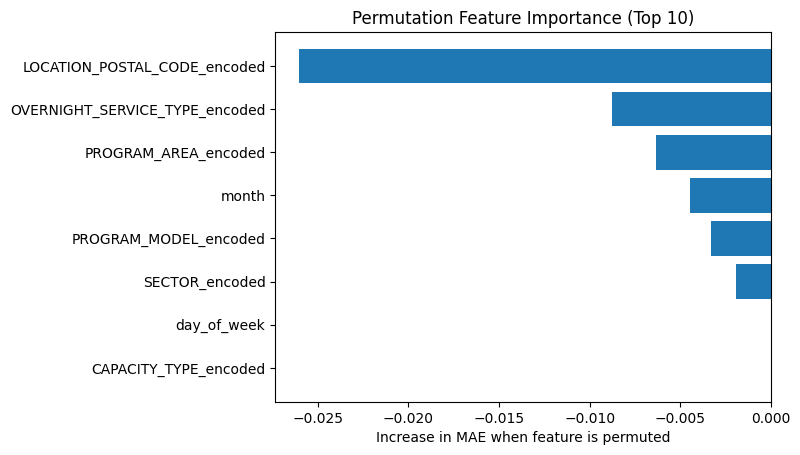

In [ ]:
import matplotlib.pyplot as plt

top = imp.head(10).iloc[::-1]  # reverse for nicer barh

plt.figure()
plt.barh(top["feature"], top["mae_increase_mean"])
plt.xlabel("Increase in MAE when feature is permuted")
plt.title("Permutation Feature Importance (Top 10)")
plt.show()